## Test reading of HYPSO-2 data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import os
import sys
sys.path.append('..')
from hypso.hypso2 import Hypso2
from hypso.hypso1 import Hypso1

## Inspect calibration coefficients

shape of h2 rad coeffs: (1216, 1936)
shape of h1_full rad coeffs: (1216, 1936)
shape of h1_nominal rad coeffs: (684, 120)
shape of h1_wide rad coeffs: (1092, 120) 

shape of h1_wide rad coeffs that I constructed: (1092, 120)
value picked out value of constructed wide matrix 0.0015825185566322299
value picked out value of available wide matrix 0.0015833043591501647
Are the marices equal:  False
Avg. difference between matrices:  1.5342775516889102e-06 

Shape of h2 wide coeff matrix:  (1092, 120) 

shape of h1 wav coeffs: [387.84749685 391.40406599 394.95941579 398.51354623 402.06645732
 405.61814905 409.16862143 412.71787446 416.26590814 419.81272246
 423.35831743 426.90269305 430.44584931 433.98778622 437.52850378
 441.06800198 444.60628083 448.14334033 451.67918047 455.21380126
 458.7472027  462.27938479 465.81034752 469.3400909  472.86861492
 476.3959196  479.92200491 483.44687088 486.97051749 490.49294475
 494.01415266 497.53414122 501.05291042 504.57046026 508.08679076
 511.601901

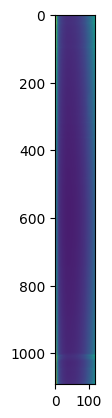

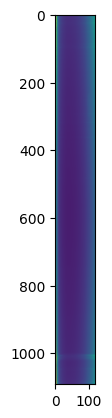

In [2]:
# inspect the different calibration coefficients..

rad_coeff_h2 = np.load('../hypso/calibration/hypso2_data/h2_radiometric_calibration_matrix_full.npz')
rad_coeff_h1_full = np.load('../hypso/calibration/hypso1_data/radiometric_calibration_matrix_HYPSO-1_full_v1.npz')
rad_coeff_h1_nominal = np.load('../hypso/calibration/hypso1_data/radiometric_calibration_matrix_HYPSO-1_nominal_v1.npz')
rad_coeff_h1_wide = np.load('../hypso/calibration/hypso1_data/radiometric_calibration_matrix_HYPSO-1_wide_v1.npz')

print('shape of h2 rad coeffs:', rad_coeff_h2['arr_0'].shape)
print('shape of h1_full rad coeffs:', rad_coeff_h1_full['arr_0'].shape)
print('shape of h1_nominal rad coeffs:', rad_coeff_h1_nominal['arr_0'].shape)
print('shape of h1_wide rad coeffs:', rad_coeff_h1_wide['arr_0'].shape, '\n')


# values from config file
bin_factor = 9
aoi_x = 428
aoi_y = 62
row_count = 1092
column_count = 1080

x_start = aoi_x
x_stop  = aoi_x + column_count
y_start = aoi_y
y_stop  = aoi_y + row_count


rad_coeff_h1_wide_1 = rad_coeff_h1_full['arr_0'][y_start:y_stop, x_start: x_stop].reshape(row_count, -1, bin_factor).mean(axis=2).reshape(row_count, -1)

# didn't make a difference to write out the binning
# rad_coeff_h1_aoi = rad_coeff_h1_full['arr_0'][y_start:y_stop, x_start: x_stop]
# j = 0
# rad_coeff_h1_wide_2 = np.zeros((row_count, 120))
# for i in range(0, column_count - 9, 9):
#     rad_coeff_h1_wide_2[:, j] = np.mean(rad_coeff_h1_aoi[:,i:i + 9], axis=1)
#     j += 1

# Compare the wide coeff matrix I constructed with the available one
print('shape of h1_wide rad coeffs that I constructed:', rad_coeff_h1_wide_1.shape)
print('value picked out value of constructed wide matrix', rad_coeff_h1_wide_1[20,20])
print('value picked out value of available wide matrix', rad_coeff_h1_wide['arr_0'][20,20])
# print(rad_coeff_h1_wide_2[20,20])
print('Are the marices equal: ', np.array_equal(rad_coeff_h1_wide_1, rad_coeff_h1_wide['arr_0']))
print('Avg. difference between matrices: ', np.mean(np.abs(rad_coeff_h1_wide_1 - rad_coeff_h1_wide['arr_0'])), '\n')

# Plot the two matrices
plt.figure()
plt.imshow(rad_coeff_h1_wide_1)
plt.figure()
plt.imshow(rad_coeff_h1_wide['arr_0'])

# construct wide matrix for h2
rad_coeff_h2_wide = rad_coeff_h2['arr_0'][y_start:y_stop, x_start: x_stop].reshape(row_count, -1, bin_factor).mean(axis=2).reshape(row_count, -1)
print('Shape of h2 wide coeff matrix: ', rad_coeff_h2_wide.shape, '\n')

# Inspect the other calibration coefficients
spec_wav_h1 = np.load('../hypso/calibration/hypso1_data/spectral_bands_HYPSO-1_v1.npz')

spec_wav_h2_binned = np.load('../hypso/calibration/hypso2_data/spectral_bands_HYPSO-2.npz')
spec_wav_h2 = np.load('../hypso/calibration/hypso2_data/h2_spectral_calibration_wavelengths_center_row.npz')
spec_coeff_h2 = np.load('../hypso/calibration/hypso2_data/h2_spectral_calibration_coefficients.npz')
pre_spec_coeff_h2 = np.load('../hypso/calibration/hypso2_data/FM_pre_spectral_coeffs.npz')
eqm_spec_coeff_h2 = np.load('../hypso/calibration/hypso2_data/EQM_spectral_coeffs_fluorescent_before_shock_vib.npz')

print('shape of h1 wav coeffs:', spec_wav_h1['arr_0'], '\n')

print('shape of h2 binned wav coeffs:', spec_wav_h2_binned['arr_0'])
print('shape of h2 binned wav coeffs:', spec_wav_h2_binned['arr_0'].shape)
print('shape of h2 wav coeffs:', spec_wav_h2['arr_0'].shape)
print('shape of h2 spec coeffs:', spec_coeff_h2['arr_0'])
print('shape of h2 pre spec coeffs:', pre_spec_coeff_h2['arr_0'])
print('shape of h2 eqm spec coeffs:', eqm_spec_coeff_h2['arr_0'])

## Load HYPSO-1 and HYPSO-2 captures

#### Load H2 data

In [3]:
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'

In [4]:
satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [5]:
satobj_h2.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...


In [6]:
calibrated_cube_h2 = np.array(satobj_h2.get_l1b_cube())

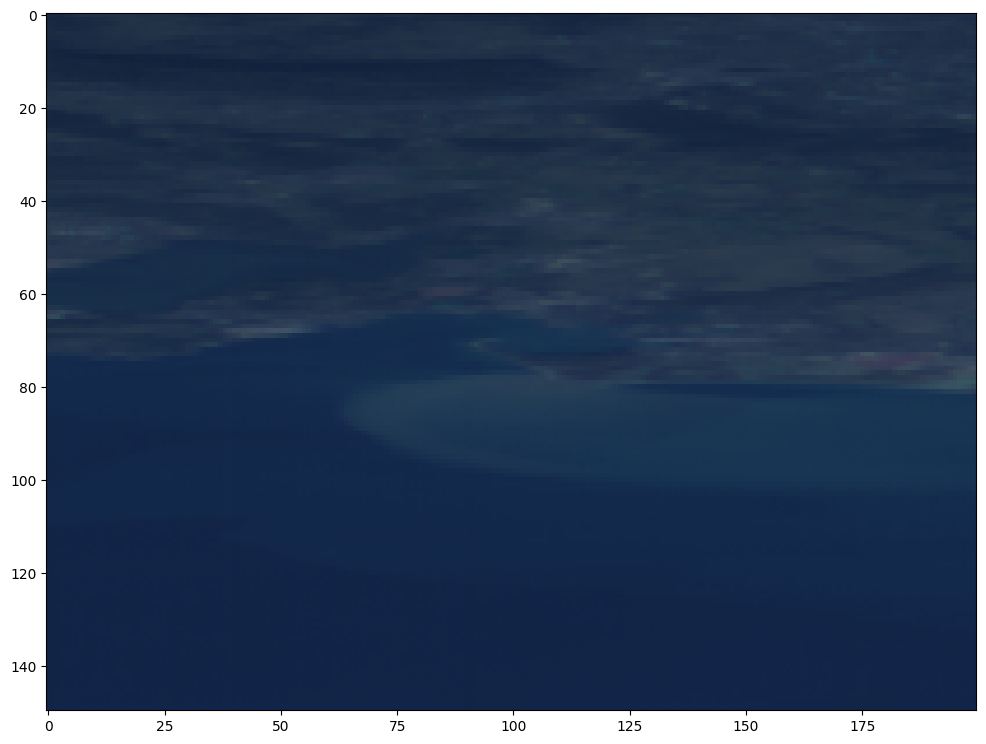

In [7]:
# same for hypso-2 capture

# TODO fix so that get_closest_wavelength_idex works for H2 too

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx =   satobj_h2.get_closest_wavelength_index(red_wl) # TODO check out this function for H2
green_idx = satobj_h2.get_closest_wavelength_index(green_wl)
blue_idx =  satobj_h2.get_closest_wavelength_index(blue_wl)

# plt.imshow(calibrated_cube_h1[:,:, [red_idx, green_idx, blue_idx]])
composite = (255*calibrated_cube_h2[250:400,500:700,[red_idx, green_idx, blue_idx]]/calibrated_cube_h2[:,:,[red_idx, green_idx, blue_idx]].max()).astype(int)
plt.figure(figsize=(12,12))
plt.imshow(composite)

x_gsp_h2, y_gsp_h2 = 305, 625

#### Load H1 data

In [8]:
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'

satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] No georeferencing .points file provided. Skipping georeferencing.


In [9]:
satobj_h1.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...


In [10]:
calibrated_cube_h1 = satobj_h1.get_l1b_cube()

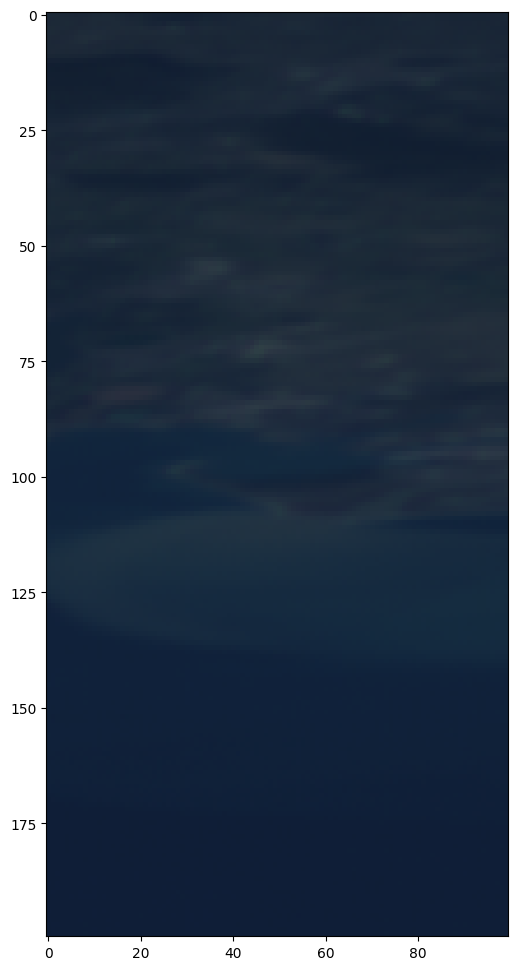

In [11]:

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx =   satobj_h1.get_closest_wavelength_index(red_wl)
green_idx = satobj_h1.get_closest_wavelength_index(green_wl)
blue_idx =  satobj_h1.get_closest_wavelength_index(blue_wl)

# plt.imshow(calibrated_cube_h1[:,:, [red_idx, green_idx, blue_idx]])
composite = (255*calibrated_cube_h1[300:500,400:500,[red_idx, green_idx, blue_idx]]/calibrated_cube_h1[:,:,[red_idx, green_idx, blue_idx]].max()).astype(int)
plt.figure(figsize=(12,12))
plt.imshow(composite)

x_gsp_h1, y_gsp_h1 = 370, 470

## Load RadCalNet data

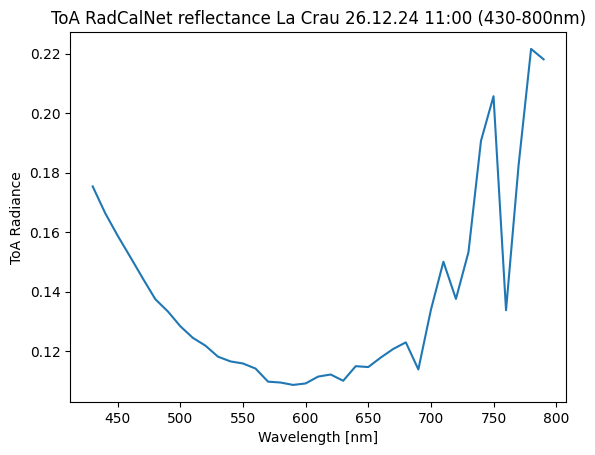

In [12]:
# Read the ASCII ToA data

file_path = '../../data/h2_lacrau_2024-12-26T11-15-54/RadCalNet/LCFR01_2024_361_v04.06.output'

def read_radcalnet_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize variables to store header and data
    header = []
    atmos_data = []
    ToA_reflectance = []
    ToA_uncertainty = []

    # State variable to track which part of the file we are reading
    state = 'header'

    for line in lines:
        stripped_line = line.strip()
        
        if state == 'header':
            if stripped_line == '':
                state = 'atmos_data'
            else:
                split_line = stripped_line.split('\t')
                header.append(split_line)
        elif state == 'atmos_data':
            if stripped_line == '':
                state = 'ToA_reflectance'
            else:
                split_line = stripped_line.split('\t')
                atmos_data.append(split_line)
        elif state == 'ToA_reflectance':
            if stripped_line == '' and len(ToA_reflectance) != 0:
                state = 'ToA_uncertainty'
            else:
                if stripped_line != '':
                    split_line = stripped_line.split('\t')
                    ToA_reflectance.append(split_line)
        elif state == 'ToA_uncertainty':
            if stripped_line != '':
                split_line = stripped_line.split('\t')
                ToA_uncertainty.append(split_line)
    header_ar = np.array(header)
    atmos_data_ar = np.array(atmos_data)
    ToA_reflectance_ar = np.array(ToA_reflectance, dtype=float)
    ToA_uncertainty_ar = np.array(ToA_uncertainty)


    return header_ar, atmos_data_ar, ToA_reflectance_ar, ToA_uncertainty_ar

header, atmos_data, ToA_reflectance, ToA_uncertainty = read_radcalnet_file(file_path)

plt.figure()
plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00 (430-800nm)')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Radiance')
plt.plot(ToA_reflectance[3:40,0], ToA_reflectance[3:40, 4])

## Compare data to RadCalNet site

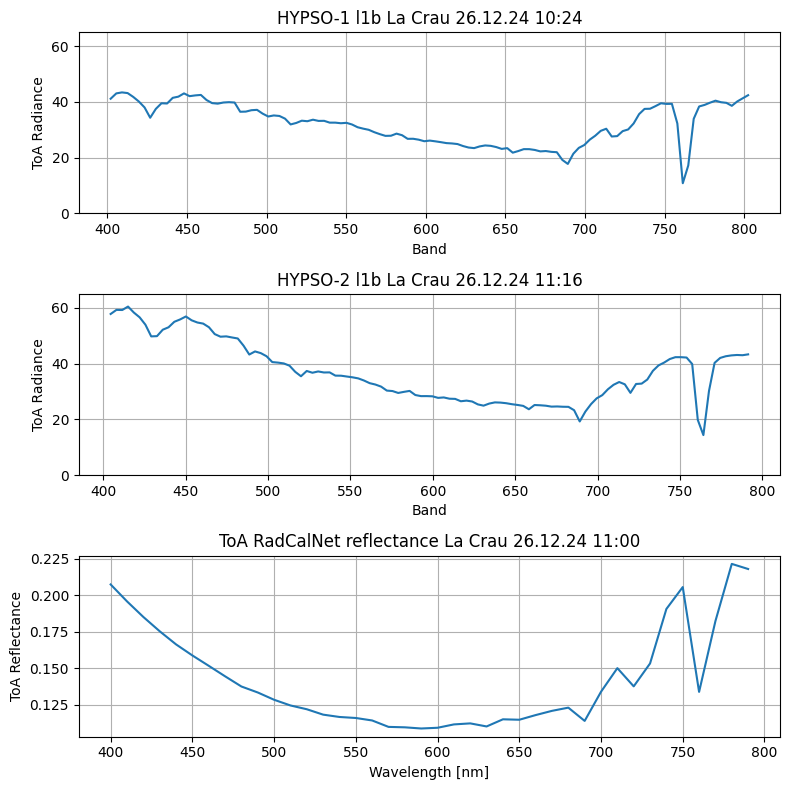

In [13]:
# TODO get reflectance instead of radiance, and get more accurate ground point

# wavelengths_h2 = satobj_h2.wavelengths[satobj_h2.x_start:satobj_h2.x_stop].reshape(-1, satobj_h2.bin_factor).mean(axis=1).reshape(-1)

plt.figure(figsize=(8,8))
plt.subplot(3,1,1)
plt.title('HYPSO-1 l1b La Crau 26.12.24 10:24')
plt.xlabel('Band')
plt.ylabel('ToA Radiance')
plt.ylim(0, 65)
plt.plot(satobj_h1.wavelengths[4:], calibrated_cube_h1[x_gsp_h1, y_gsp_h1, 4:]) # wavelength mapping is not correct ...
plt.grid()
# plt.plot(np.arange(450, 800, (800 - 450 ) / 120), calibrated_cube[305, 660, :]) # wavelength mapping is not correct ...

plt.subplot(3,1,2)
plt.title('HYPSO-2 l1b La Crau 26.12.24 11:16')
plt.xlabel('Band')
plt.ylabel('ToA Radiance')
plt.ylim(0, 65)
plt.plot(satobj_h2.wavelengths[7:], calibrated_cube_h2[x_gsp_h2, y_gsp_h2, 7:]) # wavelength mapping is not correct ...
plt.grid()
# plt.plot(np.arange(450, 800, (800 - 450 ) / 120), calibrated_cube[305, 660, :]) # wavelength mapping is not correct ...

plt.subplot(3,1,3)
plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.grid()
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])
plt.tight_layout()